# 1 · Cómo se evalúa + baselines (estadísticos y de modelos)

Antes de los modelos profundos, fijamos **cómo se mide** y los baselines. Van en
orden de complejidad creciente: primero los **estadísticos** (z-score, Mahalanobis —
sin aprendizaje), después los **de modelos** (Isolation Forest, One-Class SVM).

Métrica principal: PR-AUC (área Precision-Recall, libre de umbral). Razones:

- Las anomalías son la clase minoritaria y su prevalencia es baja e inestable: en train (histórico, ≤2020) la tasa de campañas anómalas es ~11% en soja y ~8% en maíz; en test (2021-2024, incluye la sequía 2022/23) sube a ~27% y ~30% respectivamente. En ambos escenarios los positivos son minoría frente a los negativos, y encima la proporción cambia entre train y test.

- Con clases desbalanceadas, el ROC-AUC es engañoso: su eje X es el FPR = FP / (FP + TN). Como los negativos (TN) son mayoría abrumadora (~70-90% de las muestras), hace falta acumular muchísimos falsos positivos para mover el FPR de forma apreciable, así que un modelo puede tener ROC-AUC alto aunque genere 
bastantes falsos positivos.

- La precisión, en cambio, sí es sensible a esto: se calcula como TP / (TP + FP), directamente sobre las predicciones positivas, sin que el volumen de negativos la diluya. El PR-AUC (que integra precisión vs. recall en todos los umbrales) expone mejor si el modelo distingue anomalías reales o solo se beneficia de la abundancia de negativos.

- Todo se reporta multi-seed (media ± std) porque los modelos profundos varían.

`lab.metrics(scores, y)` devuelve PR-AUC, ROC-AUC, precisión@k y recall al top-10%;
`lab.tabla(resultados)` es la **presentación estándar** del proyecto (fila = modelo,
métricas `media±std`).

In [29]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        ZScoreDetector, MahalanobisDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [30]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
soja  train: (6143, 72) | test anómalas: 251
maíz  train: (8082, 72) | test anómalas: 344


## 1.1 · Baselines estadísticos: z-score y Mahalanobis
Puramente estadísticos, sin aprendizaje ni redes; solo necesitan media (y, en Mahalanobis,
covarianza) del train normal. Ambos son **deterministas** (sin semilla → ±0.000).

- **Z-score multivariado** (`ZScoreDetector`): `z=(x−media)/desvío` por feature; el score es
  el promedio (`mean`) o el máximo (`max`) de `|z|` entre las 54 features. No ve correlaciones.
- **Mahalanobis** (`MahalanobisDetector`): distancia con la **covarianza completa**
  (encogimiento Ledoit-Wolf para invertirla estable con 54 features) — "z-score con
  correlaciones".

Los resultados se muestran con `lab.tabla`, la **presentación estándar del proyecto** (una
fila por modelo, métricas `media±std`).

In [31]:
estadisticos = {
    "ZScore (mean)": [lab.metrics(ZScoreDetector(agg="mean").fit(ds.X_train)
                                  .score_samples(ds.X_test), ds.y_test)],
    "ZScore (max)":  [lab.metrics(ZScoreDetector(agg="max").fit(ds.X_train)
                                  .score_samples(ds.X_test), ds.y_test)],
    "Mahalanobis":   [lab.metrics(MahalanobisDetector(shrinkage=None).fit(ds.X_train)
                                  .score_samples(ds.X_test), ds.y_test)],
}
lab.tabla(estadisticos)

,pr_auc,roc_auc
ZScore (mean),0.553±0.000,0.704±0.000
Mahalanobis,0.348±0.000,0.623±0.000
ZScore (max),0.336±0.000,0.638±0.000


## 1.2 · Baselines de modelos: Isolation Forest y One-Class SVM
El siguiente escalón: modelos que *aprenden* la región normal.

- **Isolation Forest** — ensamble de árboles que aísla puntos raros; estocástico, así que va
  **multi-seed** (3 semillas acá para el "Run all"; el estudio usa 10). El único HP con
  efecto real fue `max_features=0.3`.
- **One-Class SVM** — frontera que envuelve a los normales; con kernel **RBF** es no lineal.
  Comparamos RBF vs lineal para ver que la no-linealidad importa (determinista).

In [32]:
modelos = {
    "IForest": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3,
                random_state=s).fit(ds.X_train).score_samples(ds.X_test), ds.y_test)
                for s in SEEDS[:3]],
    "OCSVM (rbf)":    [lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
                                   .fit(ds.X_train).score_samples(ds.X_test), ds.y_test)],
    "OCSVM (linear)": [lab.metrics(OneClassSVMDetector(kernel="linear", nu=0.1)
                                   .fit(ds.X_train).score_samples(ds.X_test), ds.y_test)],
}
lab.tabla(modelos)

,pr_auc,roc_auc
IForest,0.517±0.026,0.665±0.041
OCSVM (rbf),0.485±0.000,0.695±0.000
OCSVM (linear),0.180±0.000,0.249±0.000


**El kernel lineal fracasa** y el **RBF es competitivo con el IForest**: la frontera no
lineal es imprescindible. Y el **z-score (mean)** de 1.1, sin aprender nada, ya juega en la
misma liga que el IForest (lo interpretamos en 1.5).

## 1.3 · Comparación de todos los baselines (soja y maíz)
Todos los baselines juntos, en la tabla estándar. Acá **solo comparamos baselines entre sí**
(el listón a superar); los modelos de reconstrucción del nb 2 en adelante se miden contra
este piso en sus propios notebooks.

In [33]:
def baselines_dict(dset):
    return {
        "ZScore (mean)": [lab.metrics(ZScoreDetector(agg="mean").fit(dset.X_train)
                                      .score_samples(dset.X_test), dset.y_test)],
        "ZScore (max)":  [lab.metrics(ZScoreDetector(agg="max").fit(dset.X_train)
                                      .score_samples(dset.X_test), dset.y_test)],
        "Mahalanobis":   [lab.metrics(MahalanobisDetector(shrinkage=None).fit(dset.X_train)
                                      .score_samples(dset.X_test), dset.y_test)],
        "IForest": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3,
                    random_state=s).fit(dset.X_train).score_samples(dset.X_test), dset.y_test)
                    for s in SEEDS[:3]],
        "OCSVM (rbf)": [lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
                                    .fit(dset.X_train).score_samples(dset.X_test), dset.y_test)],
    }

res = {"soja": baselines_dict(ds), "maíz": baselines_dict(dsm)}
lab.tabla(res["soja"])

,pr_auc,roc_auc
ZScore (mean),0.553±0.000,0.704±0.000
IForest,0.517±0.026,0.665±0.041
OCSVM (rbf),0.485±0.000,0.695±0.000
Mahalanobis,0.348±0.000,0.623±0.000
ZScore (max),0.336±0.000,0.638±0.000


Y en maíz:

In [34]:
lab.tabla(res["maíz"])

,pr_auc,roc_auc
ZScore (mean),0.515±0.000,0.645±0.000
IForest,0.506±0.041,0.653±0.031
OCSVM (rbf),0.436±0.000,0.612±0.000
Mahalanobis,0.321±0.000,0.540±0.000
ZScore (max),0.299±0.000,0.521±0.000


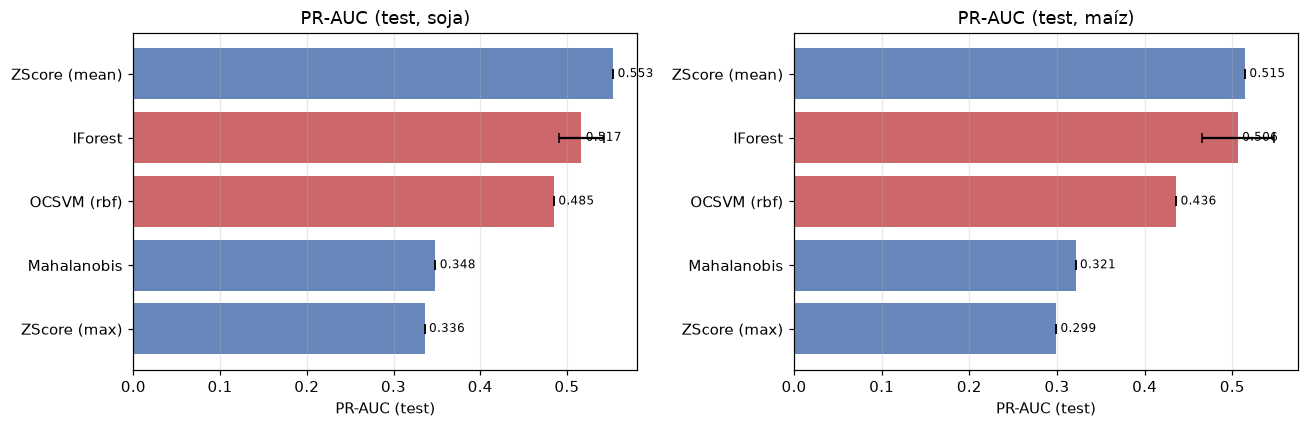

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for ax, (nombre, r) in zip(axs, res.items()):
    lab.plot_leaderboard(lab.leaderboard(r), ax=ax, titulo=f"PR-AUC (test, {nombre})")
plt.tight_layout(); plt.show()

## 1.4 · Matrices de confusión de los baselines
El PR-AUC mide el *ranking* (libre de umbral). Para una matriz de confusión hace falta un
**corte**, y un umbral absoluto no transfiere entre períodos (los scores se corren hacia
arriba en 2021–24 → un corte fijo marca ~70% del test). Por eso re-umbralizamos sobre el
**propio test** al top-tasa real (~27%, `q="base"`), para **todos los baselines** (soja):

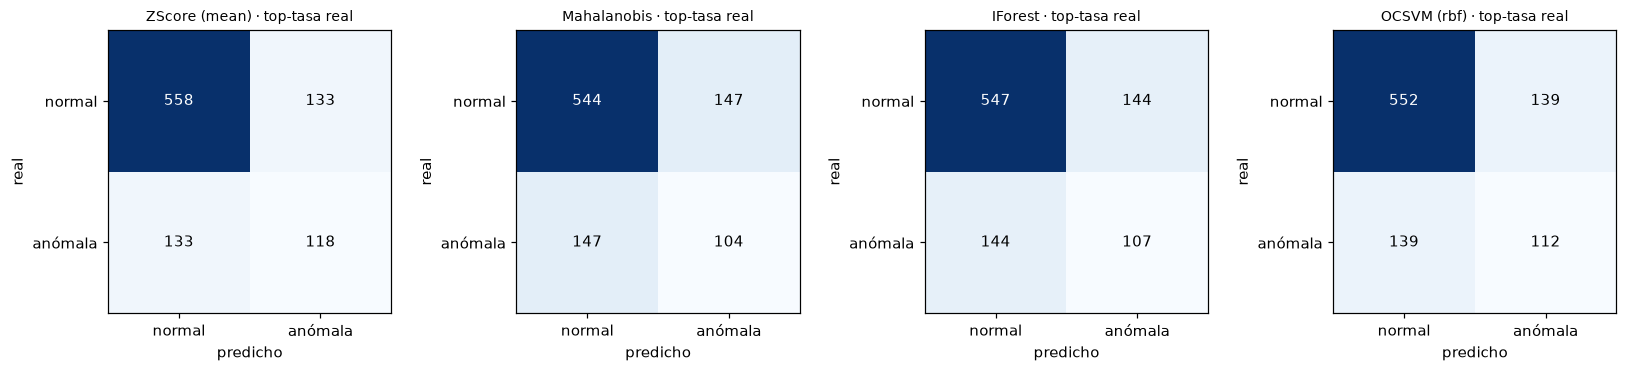

In [36]:
scores_conf = {
    "ZScore (mean)": ZScoreDetector(agg="mean").fit(ds.X_train).score_samples(ds.X_test),
    "Mahalanobis":   MahalanobisDetector(shrinkage=None).fit(ds.X_train).score_samples(ds.X_test),
    "IForest":       IsolationForestDetector(n_estimators=200, max_features=0.3,
                                             random_state=42).fit(ds.X_train).score_samples(ds.X_test),
    "OCSVM (rbf)":   OneClassSVMDetector(kernel="rbf", nu=0.1).fit(ds.X_train).score_samples(ds.X_test),
}
fig, axs = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, (nombre, sc) in zip(axs, scores_conf.items()):
    lab.confusion_top(sc, ds.y_test, "base", ax=ax, titulo=nombre)
plt.tight_layout(); plt.show()

## 1.5 · Interpretación 
El Z-Score (mean) queda a la par del Isolation Forest (en soja incluso lo supera levemente) pese a no aprender nada. Esto se puede deber, sobre todo, a que las features climáticas ya funcionan como un índice de anomalía razonable cuando ésta se debe a una sequía: el promedio de desviaciones estandarizadas capta directamente la magnitud del evento climático, sin necesidad de un modelo que aprenda estructura adicional.

Sin embargo, el Z-Score max muestra el límite de esa idea: una única feature rara no alcanza para marcar una anomalía de rinde. Tomar el máximo (en vez del promedio) sobredetecta, porque cualquier variable puede tener un pico aislado sin que eso implique una caída real de rinde — la señal útil está en la desviación conjunta, no en el extremo de una sola dimensión.

Mahalanobis, en cambio, queda por debajo: al normalizar cada dirección por su propia varianza, des-pondera justo las direcciones de mayor varianza — que son donde vive la firma de sequía (las features climáticas varían mucho de por sí, año a año). El resultado es que Mahalanobis le resta importancia exactamente a la señal que más importa, y puede en cambio reaccionar a variables poco variables que se mueven levemente. Lección de fondo, válida para los tres baselines: rareza estadística (multivariada o univariada) no es lo mismo que anomalía de rinde — hay que ponderar las direcciones que importan agronómicamente, no las que son raras en términos puramente estadísticos.